# Verify `NWeak/cub-mirror` on the Hub

Loads the dataset we just pushed with `scripts/push_to_hub.py` back from
HuggingFace and sanity-checks that images, embeddings, and official CUB
labels/concepts survived the round trip intact.

In [1]:
from datasets import load_dataset

REPO_ID = "NWeak/cub-mirror"

ds = load_dataset(REPO_ID)
ds

/home/nicola.debole/projects/user-study-CBMs/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 976 examples [00:00, 2080.27 examples/s]

Generating train split: 1952 examples [00:00, 3356.21 examples/s]

Generating train split: 3904 examples [00:00, 6278.82 examples/s]

...

Generating test split: 5794 examples [00:00, 6483.90 examples/s]

Generating val split: 0 examples [00:00, ? examples/s]

Generating val split: 947 examples [00:00, 4934.47 examples/s]

Generating val split: 1198 examples [00:00, 5558.26 examples/s]

DatasetDict({
    train: Dataset({
        features: ['sample_idx', 'split', 'label', 'class_name', 'image_path', 'dagger beak', 'hooked seabird beak', 'all-purpose beak', 'cone beak', 'brown wing', 'grey wing', 'yellow wing', 'black wing', 'white wing', 'buff wing', 'brown upperparts', 'grey upperparts', 'yellow upperparts', 'black upperparts', 'white upperparts', 'buff upperparts', 'brown underparts', 'grey underparts', 'yellow underparts', 'black underparts', 'white underparts', 'buff underparts', 'solid breast', 'striped breast', 'multi-colored breast', 'brown back', 'grey back', 'yellow back', 'black back', 'white back', 'buff back', 'notched tail', 'brown upper-tail', 'grey upper-tail', 'black upper-tail', 'white upper-tail', 'buff upper-tail', 'eyebrow head', 'plain head', 'brown breast', 'grey breast', 'yellow breast', 'black breast', 'white breast', 'buff breast', 'grey throat', 'yellow throat', 'black throat', 'white throat', 'buff throat', 'black eye', 'beak length about the

## Split sizes match what `encode_clip.py` produced locally

train=4796, val=1198, test=5794 (11788 total, the full CUB-200-2011 dataset).

In [2]:
expected_sizes = {"train": 4796, "val": 1198, "test": 5794}
for split, n in expected_sizes.items():
    actual = ds[split].num_rows
    status = "OK" if actual == n else "MISMATCH"
    print(f"{split}: expected {n}, got {actual} [{status}]")

train: expected 4796, got 4796 [OK]
val: expected 1198, got 1198 [OK]
test: expected 5794, got 5794 [OK]


## Inspect a single row

Should have a decoded PIL image, a 768-d CLIP (ViT-L/14) embedding, the class
label/name, and 112 concept columns.

label: 21 class_name: Chuck will Widow
image_path: CUB_200_2011/images/022.Chuck_will_Widow/Chuck_Will_Widow_0059_796982.jpg
image: <class 'PIL.Image.Image'> (500, 382)
embedding dim: 768
num concept columns: 112
active concepts: ['cone beak', 'brown wing', 'brown upperparts', 'brown underparts', 'brown back', 'brown upper-tail', 'brown breast', 'black eye', 'beak length shorter than head', 'brown forehead'] ...


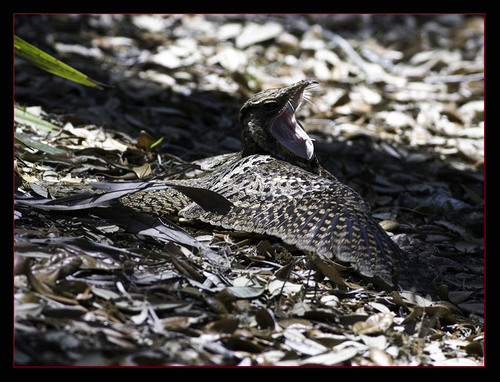

In [3]:
row = ds["train"][0]

non_concept_cols = {"sample_idx", "split", "label", "class_name", "image_path", "image", "embedding"}
concept_cols = [c for c in ds["train"].column_names if c not in non_concept_cols]

print("label:", row["label"], "class_name:", row["class_name"])
print("image_path:", row["image_path"])
print("image:", type(row["image"]), row["image"].size)
print("embedding dim:", len(row["embedding"]))
print("num concept columns:", len(concept_cols))
print("active concepts:", [c for c in concept_cols if row[c] == 1][:10], "...")

row["image"]

## Cross-check against the local CSVs / embedding files

Confirms the Hub round-trip (image bytes re-encoded to parquet, embedding
floats, label/concept ints) didn't silently corrupt anything, by comparing a
handful of rows against `data/cub_csv/*.csv` and `data/clip_embeddings/*.pt`.

In [4]:
import numpy as np
import pandas as pd
import torch

SPLIT = "train"
N_CHECK = 20

local_df = pd.read_csv(f"../data/cub_csv/{SPLIT}.csv")
local_embeddings = torch.load(f"../data/clip_embeddings/cub_{SPLIT}_ViT-L%14.pt", weights_only=True)

mismatches = []
for i in range(N_CHECK):
    hub_row = ds[SPLIT][i]
    local_row = local_df.iloc[i]

    if hub_row["label"] != local_row["label"] or hub_row["class_name"] != local_row["class_name"]:
        mismatches.append(("label/class_name", i))
    if hub_row["image_path"] != local_row["image_path"]:
        mismatches.append(("image_path", i))
    if any(hub_row[c] != int(local_row[c]) for c in concept_cols):
        mismatches.append(("concepts", i))
    if not np.allclose(hub_row["embedding"], local_embeddings[i].numpy(), atol=1e-4):
        mismatches.append(("embedding", i))

print(f"Checked {N_CHECK} rows from '{SPLIT}', {len(mismatches)} mismatches" + (f": {mismatches}" if mismatches else " -- all match."))

Checked 20 rows from 'train', 0 mismatches -- all match.


## Dataset card

Sanity-check that `push_to_hub.py`'s attribution/license card actually made it
to the repo.

In [5]:
from huggingface_hub import DatasetCard

card = DatasetCard.load(REPO_ID)
print(card.data)
print(card.text[:500])

license: other
license_name: cub-200-2011-research-use
license_link: https://www.vision.caltech.edu/datasets/cub_200_2011/
tags:
- concept-bottleneck-models
- cub-200-2011
- clip

# NWeak/cub-mirror

CLIP (`ViT-L/14`) embeddings of [CUB-200-2011](https://www.vision.caltech.edu/datasets/cub_200_2011/)
images, joined with the dataset's official class labels and 112 concept
(attribute) annotations. Each row: `image`, `image_path`, `embedding`,
`label`, `class_name`, and one 0/1 column per concept.

## Attribution & license

Images and the original concept/class annotations are from CUB-200-2011
(Wah et al., 2011, Caltech-UCSD). The photographs were collected from the web
an
